# [Hands-On] Enhancing Gradient Flow with Residual Connections and Swish Activation in Deep Neural Networks

- Author : Sangkeun Jung (hugmanskj@gmail.com)

> Educational Purpose

**Copyright**: All rights reserved

---

## Overview

In this hands-on tutorial, we will explore the phenomenon of gradient vanishing in deep neural networks and investigate strategies to mitigate it. Specifically, we will:

- Implement a simple deep neural network using the Sigmoid activation function and observe the gradient vanishing problem.
- Introduce Residual Connections to the network and analyze their effect on gradient flow.
- Experiment with the Swish activation function as an alternative to Sigmoid and examine its impact.
- Combine Residual Connections with the Swish activation function to see how they work together to improve gradient flow.
- Visualize the gradient norms throughout the training process to better understand how these techniques affect the gradients.

This tutorial is designed for educational purposes and aims to provide practical insights into how to address the gradient vanishing problem in deep learning.

## Utility Functions and Imports

In this section, we import the necessary libraries and define utility functions that will be used throughout the tutorial:

- **Imports**: Essential libraries such as `torch`, `torch.nn`, `torch.optim`, `matplotlib.pyplot`, and `numpy` are imported.
- **`set_seed` Function**: Ensures reproducibility by setting the random seed for Python's `random`, NumPy, and PyTorch (both CPU and CUDA).
- **Plotting Functions**:
  - **`plot_gradients`**: Plots the gradient norms for each layer over epochs, helping visualize how gradients change during training.
  - **`compare_gradients`**: Compares gradient norms across different models for a specific layer, allowing us to see the effects of different techniques on gradient flow.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

def set_seed(seed):
    import random
    import numpy as np
    import torch

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Define the plotting function
def plot_gradients(gradients, N):
    # Prepare for plotting
    epochs = np.arange(len(gradients['layer_1']))

    # Create two plots side by side
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # First plot: Gradient norms by layer
    for i in range(N):
        ax[0].plot(epochs, gradients[f'layer_{i+1}'], label=f'Layer {i+1} Gradients')
    ax[0].plot(epochs, gradients['output_layer'], label='Output Layer Gradients')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Gradient Norm')
    ax[0].set_title(f'Gradient Norms by Layer (N={N})')
    ax[0].legend()
    ax[0].grid(True)

    # Second plot: Gradient norms with curve fit (polynomial trendline)
    for i in range(N):
        layer = f'layer_{i+1}'
        # Fit a 3rd-degree polynomial trendline for each layer
        z = np.polyfit(epochs, gradients[layer], 3)
        p = np.poly1d(z)
        ax[1].plot(epochs, p(epochs), linestyle='--', label=f'Layer {i+1} Trendline')
    # Output layer trendline
    z = np.polyfit(epochs, gradients['output_layer'], 3)
    p = np.poly1d(z)
    ax[1].plot(epochs, p(epochs), linestyle='--', label='Output Layer Trendline')

    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Gradient Norm')
    ax[1].set_title(f'Trendlines (Polynomial Fit) (N={N})')
    ax[1].legend()
    ax[1].grid(True)

    # Display both plots
    plt.tight_layout()
    plt.show()

# Plotting functions remain the same
def plot_gradients(gradients, N, title_suffix=''):
    # Prepare for plotting
    epochs = np.arange(len(gradients['layer_1']))

    # Create a plot
    plt.figure(figsize=(10, 6))

    # Plot trendlines only
    for i in range(N):
        layer = f'layer_{i+1}'
        # Fit a 3rd-degree polynomial trendline for each layer
        z = np.polyfit(epochs, gradients[layer], 3)
        p = np.poly1d(z)
        plt.plot(epochs, p(epochs), linestyle='-', label=f'Layer {i+1} Trendline')
    # Output layer trendline
    z = np.polyfit(epochs, gradients['output_layer'], 3)
    p = np.poly1d(z)
    plt.plot(epochs, p(epochs), linestyle='-', label='Output Layer Trendline')

    plt.xlabel('Epoch')
    plt.ylabel('Gradient Norm')
    plt.title(f'Trendlines (Polynomial Fit) {title_suffix}(N={N})')
    plt.legend()
    plt.grid(True)
    plt.show()


def compare_gradients(data, layer_number):
    epochs = np.arange(len(next(iter(data.values()))[f'layer_{layer_number}']))

    plt.figure(figsize=(10, 6))

    for model_name, gradients in data.items():
        # Get gradients for the specified layer
        layer_key = f'layer_{layer_number}'
        if layer_key in gradients:
            gradient_values = gradients[layer_key]
            # Fit trendline
            z = np.polyfit(epochs, gradient_values, 3)
            p = np.poly1d(z)
            plt.plot(epochs, p(epochs), linestyle='-', label=f'{model_name.capitalize()} Model Trendline')
        else:
            print(f"Layer {layer_number} not found in {model_name} gradients.")

    plt.xlabel('Epoch')
    plt.ylabel('Gradient Norm')
    plt.title(f'Gradient Norm Trendline Comparison for Layer {layer_number}')
    plt.legend()
    plt.grid(True)
    plt.show()

### Data Preparation and Seed Setting

In this cell, we:

- **Set the Random Seed**: Use `set_seed(42)` to ensure that the results are reproducible.
- **Generate Synthetic Data**: Create random input data `data_x` with 100 samples and 10 features, and target data `data_y` with 100 samples and 1 output.
- **Define the Number of Layers**: Set `N = 5`, which determines the depth of our neural networks.


In [ ]:
set_seed(42)

# Generate random input data
data_x = torch.randn(100, 10)
data_y = torch.randn(100, 1)

N = 5

### Model Training Function

We define the `train_model(model)` function, which encapsulates the training loop and gradient recording:

- **Initialize Training Components**:
  - Define the loss function (`nn.MSELoss()`).
  - Set up the optimizer (`optim.SGD` with a learning rate of 0.01).
- **Prepare Gradient Storage**:
  - Initialize a dictionary `gradients` to store gradient norms for each layer during training.
- **Training Loop**:
  - Runs for 100 epochs.
  - Performs forward pass, computes loss, backpropagates gradients, and updates model parameters.
- **Gradient Recording**:
  - After each epoch, record the norm of gradients for each layer and the output layer.
- **Return**:
  - The `gradients` dictionary containing gradient norms over epochs, which will be used for visualization.


In [ ]:
def train_model(model):
    # Initialize the model, loss function, and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    # Store gradient norms for each layer
    gradients = {f'layer_{i+1}': [] for i in range(N)}
    gradients['output_layer'] = []

    # Training loop
    for epoch in range(100):
        optimizer.zero_grad()  # Reset gradients before each iteration
        outputs = model(data_x)
        loss = criterion(outputs, data_y)  # Compute loss
        loss.backward()  # Backpropagate the gradients
        optimizer.step()  # Update model parameters

        # Record the gradient norms for each layer
        for name, param in model.named_parameters():
            if param.requires_grad and param.grad is not None:
                if 'layers' in name:
                    layer_num = int(name.split('.')[1])
                    gradients[f'layer_{layer_num+1}'].append(param.grad.norm().item())
                elif 'output_layer' in name:
                    gradients['output_layer'].append(param.grad.norm().item())
    return gradients

## Simple Neural Network

In this section, we define and train a simple deep neural network without any residual connections:

- **Architecture**:
  - The network has `N` layers (in this case, 5 layers), each consisting of a linear layer followed by a **Sigmoid activation function**.
  - The input dimension is 10, and each hidden layer also has 10 units.
  - The output layer maps from 10 units to 1 output and uses a Sigmoid activation function.
- **Purpose**:
  - To observe the gradient vanishing problem that commonly occurs in deep networks using the Sigmoid activation function.


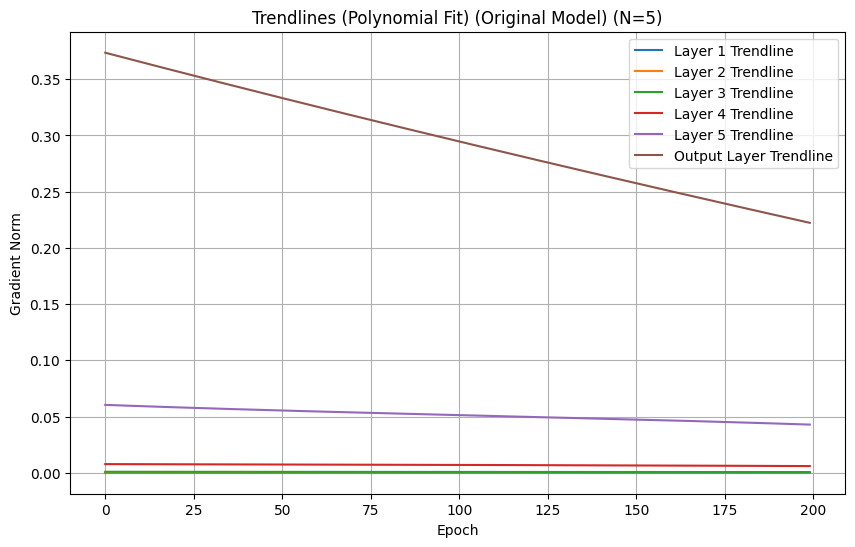

In [ ]:
# Define the neural network with N layers (without Residual Connections)
class SimpleNN(nn.Module):
    def __init__(self, N):
        super(SimpleNN, self).__init__()
        self.N = N  # Number of layers
        self.layers = nn.ModuleList()
        self.activations = nn.ModuleList()
        for _ in range(N):
            self.layers.append(nn.Linear(10, 10))
            self.activations.append(nn.Sigmoid())
        # Output layer
        self.output_layer = nn.Linear(10, 1)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        for i in range(self.N):
            x = self.activations[i](self.layers[i](x))
        x = self.output_activation(self.output_layer(x))
        return x

model = SimpleNN(N)

original_gradients = train_model(model)

# Call the plotting function
plot_gradients(original_gradients, N, title_suffix='(Original Model) ')

As training progresses and the loss decreases, it is expected that the gradient norms will also decrease. This is because as the model approaches convergence, the updates to the weights become smaller.

Additionally, we observe that the lower layers (closer to the input) receive smaller gradients compared to the higher layers. This indicates that the gradients are diminishing as they are backpropagated through the layers, which is a characteristic of the **vanishing gradient problem** in deep networks using the Sigmoid activation function.


## Residual Connections

In this cell, we modify the neural network to include **Residual Connections**:

- **Architecture Changes**:
  - Each layer now adds the input (`residual`) to its output (`out`), forming a shortcut connection.
  - The residual is updated at each layer to propagate this connection through the network.
- **Activation Function**:
  - We continue to use the Sigmoid activation function in each layer.
- **Purpose**:
  - To investigate how residual connections affect gradient flow and whether they can mitigate the vanishing gradient problem.


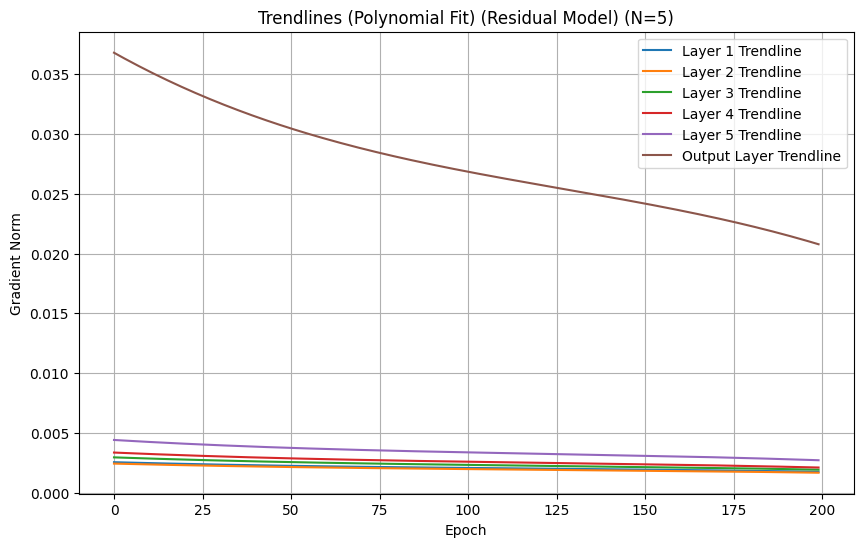

In [ ]:
class ResidualNN(nn.Module):
    def __init__(self, N):
        super(ResidualNN, self).__init__()
        self.N = N  # Number of layers
        self.layers = nn.ModuleList()
        self.activations = nn.ModuleList()
        for _ in range(N):
            self.layers.append(nn.Linear(10, 10))
            self.activations.append(nn.Sigmoid())
        # Output layer
        self.output_layer = nn.Linear(10, 1)
        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        residual = x
        for i in range(self.N):
            out = self.activations[i](self.layers[i](x))
            x = out + residual  # Residual connection
            residual = x  # Update residual for next layer
        x = self.output_activation(self.output_layer(x))
        return x

model = ResidualNN(N)

residual_gradients = train_model(model)
# Call the plotting function
plot_gradients(residual_gradients, N, title_suffix='(Residual Model) ')

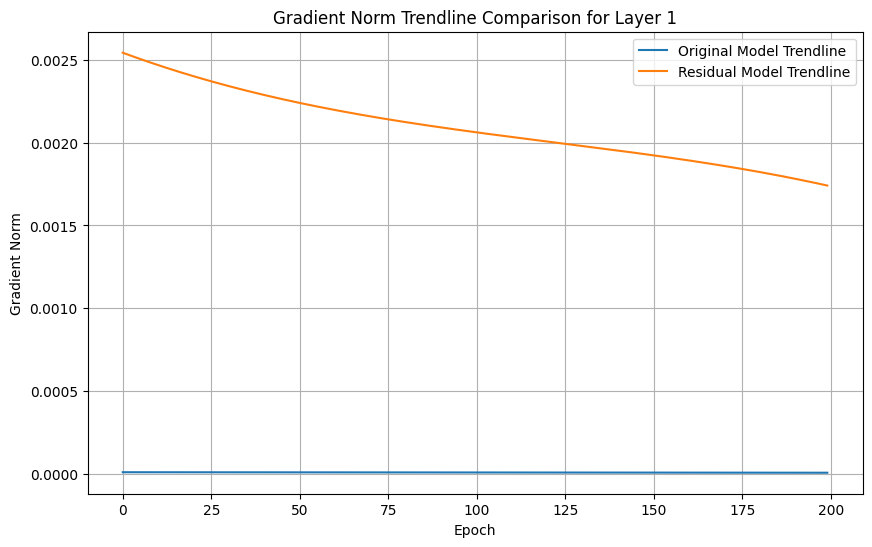

In [ ]:
data = {
    'original' : original_gradients,
    'residual' : residual_gradients,
}
compare_gradients(data, layer_number=1)

By comparing the gradient norms between the original model and the residual model, we notice that even in the **first layer** (the lowest layer), the residual model maintains a higher gradient norm. This indicates that the residual connections are effectively allowing gradients to propagate back to the earlier layers, mitigating the vanishing gradient problem. The gradients are not diminishing as rapidly, which can lead to better learning in the initial layers.


## Activation Function Change

In this section, we modify the original network by changing the activation function from Sigmoid to **Swish**:

- **Swish Activation Function**:
  - Defined as $$  f(x) = x \cdot \text{sigmoid}(x)  $$
  - Known for mitigating the vanishing gradient problem better than Sigmoid in deep networks.
- **Implementation**:
  - Replace all Sigmoid activations in the network with the Swish activation function.
- **Purpose**:
  - To examine whether using Swish can improve gradient flow without altering the network architecture.

For more detailed information about Swish activation, refer to this link:
[[Hands-On] Activation Function Exploration: ReLU vs. Swish](https://colab.research.google.com/drive/1FdwduNOf6TypsEOZ90i3VzTmOtlZkzLg)


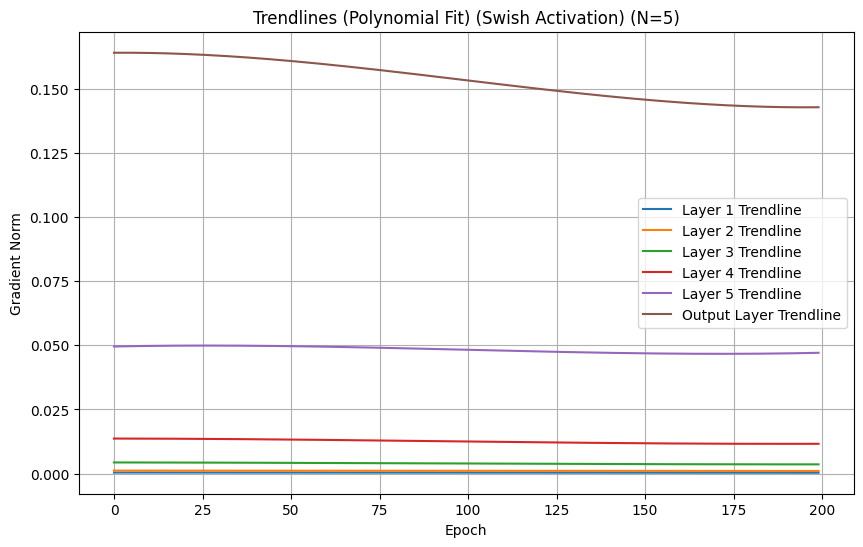

In [ ]:
# Define the Swish activation function
class Swish(nn.Module):
    def forward(self, x):
        # Swish activation: x * sigmoid(x)
        return x * torch.sigmoid(x)

# Define the neural network with N layers using Swish activation (without Residual Connections)
class SwishNN(nn.Module):
    def __init__(self, N):
        super(SwishNN, self).__init__()
        self.N = N  # Number of layers
        # Create a list of linear layers
        self.layers = nn.ModuleList()
        for _ in range(N):
            self.layers.append(nn.Linear(10, 10))
        # Use Swish activation function
        self.activation = Swish()
        # Output layer
        self.output_layer = nn.Linear(10, 1)
        self.output_activation = nn.Sigmoid()  # Use Sigmoid for output activation

    def forward(self, x):
        # Forward pass through each layer with Swish activation
        for i in range(self.N):
            x = self.activation(self.layers[i](x))
        # Pass through the output layer
        x = self.output_activation(self.output_layer(x))
        return x

model = SwishNN(N)

swish_gradients = train_model(model)
# Call the plotting function
plot_gradients(swish_gradients, N, title_suffix='(Swish Activation) ')

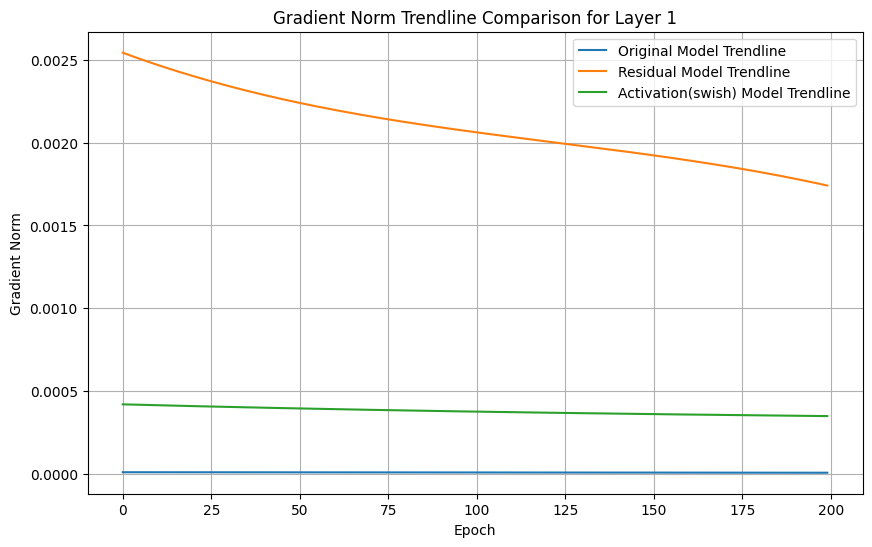

In [ ]:
data = {
    'original' : original_gradients,
    'residual' : residual_gradients,
    'activation(swish)' : swish_gradients,
}
compare_gradients(data, layer_number=1)

When comparing all models, we observe that using the Swish activation function results in larger gradient norms compared to the original model with Sigmoid activation. This means that Swish helps in keeping the gradients from vanishing as quickly.

However, the model with residual connections still shows a greater improvement in gradient flow than just changing the activation function. This suggests that while Swish mitigates the vanishing gradient problem to some extent, residual connections have a more significant effect.


## Combining Residual Connections with Swish Activation Function

Now, we aim to explore the combined effect of using both **Residual Connections** and the **Swish activation function** in the neural network:

- **Objective**:
  - To investigate whether combining these two techniques can further improve gradient flow and effectively mitigate the vanishing gradient problem.
- **Approach**:
  - Implement a neural network that incorporates residual connections at each layer and uses Swish as the activation function.
- **Expectation**:
  - By leveraging both architectural and activation function improvements, we anticipate achieving better gradient propagation compared to using either technique alone.


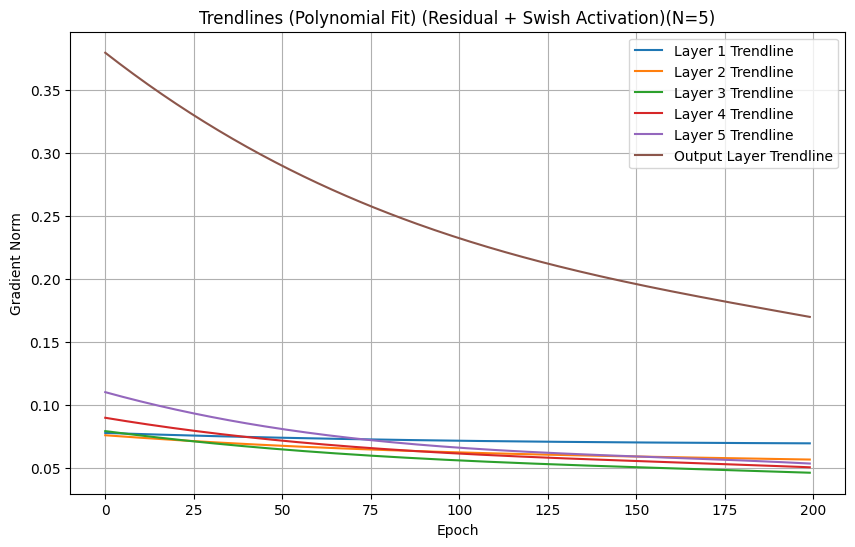

In [ ]:
# Define the Swish activation function
class Swish(nn.Module):
    def forward(self, x):
        # Swish activation: x * sigmoid(x)
        return x * torch.sigmoid(x)

# Define the neural network with N layers, using Swish activation and Residual Connections
class ResidualSwishNN(nn.Module):
    def __init__(self, N):
        super(ResidualSwishNN, self).__init__()
        self.N = N  # Number of layers
        # Create a list of linear layers
        self.layers = nn.ModuleList()
        for _ in range(N):
            self.layers.append(nn.Linear(10, 10))
        # Use Swish activation function
        self.activation = Swish()
        # Output layer
        self.output_layer = nn.Linear(10, 1)
        self.output_activation = nn.Sigmoid()  # Use Sigmoid for output activation

    def forward(self, x):
        residual = x  # Initialize residual with input x
        for i in range(self.N):
            out = self.activation(self.layers[i](x))
            x = out + residual  # Residual connection: add input to the output
            residual = x  # Update residual for the next layer
        # Pass through the output layer
        x = self.output_activation(self.output_layer(x))
        return x


model = ResidualSwishNN(N)

residual_swish_gradients = train_model(model)
# Call the plotting function
plot_gradients(residual_swish_gradients, N, title_suffix='(Residual + Swish Activation)')

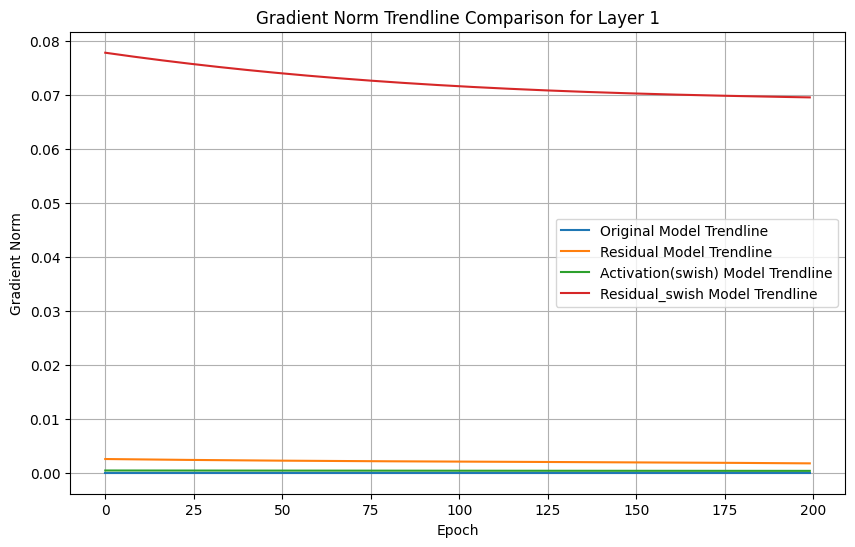

In [ ]:
data = {
    'original' : original_gradients,
    'residual' : residual_gradients,
    'activation(swish)' : swish_gradients,
    'residual_swish': residual_swish_gradients
}
compare_gradients(data, layer_number=1)

By comparing the results from all experiments, we find that the combination of **Residual Connections** and the **Swish activation function** provides the most substantial improvement in gradient flow. The gradient norms in the lower layers are significantly higher compared to the other models.

This indicates that integrating both residual connections and advanced activation functions like Swish synergistically enhances gradient propagation throughout the network, effectively addressing the vanishing gradient problem.


## Conclusion

In this tutorial, we explored the vanishing gradient problem in deep neural networks and investigated various strategies to mitigate it:

- **Original Model**:
  - A deep neural network using the Sigmoid activation function suffered from vanishing gradients, especially in the lower layers.
- **Residual Connections**:
  - Introducing residual connections significantly improved gradient flow, allowing gradients to propagate more effectively to the earlier layers.
- **Swish Activation Function**:
  - Replacing the Sigmoid activation function with Swish partially alleviated the vanishing gradient problem, improving gradient norms compared to the original model.
- **Combining Residual Connections and Swish**:
  - The combination of residual connections and the Swish activation function yielded the best results, ensuring robust gradient flow throughout the network.

**Key Takeaways**:

- **Architectural Changes** (e.g., residual connections) can have a significant impact on mitigating the vanishing gradient problem.
- **Advanced Activation Functions** (e.g., Swish) can complement architectural changes to further enhance gradient propagation.
- **Visualization of Gradient Norms** is a valuable tool for diagnosing and understanding training dynamics in deep neural networks.

By applying these strategies, we can build deeper neural networks that train effectively, paving the way for more complex and powerful models in deep learning.

---
